<a href="https://colab.research.google.com/github/SamanaDahal1/AI-and-ML/blob/main/2409014_SamanaDahal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install contractions

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 7.0 MB/s eta 0:00:00


In [3]:
!pip install gensim

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 68.2 MB/s eta 0:00:00


In [4]:
!pip install contractions

In [5]:
!pip install gensim

In [6]:
!pip install gradio

In [7]:


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import contractions
import tensorflow as tf
import random

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
# =========================
# 2. SET SEEDS
# =========================
random.seed(42)
np.random.seed(42)
tf.random.set_seed(42)

In [8]:
# =========================
# 3. LOAD DATA
# =========================
df = pd.read_csv('/content/drive/MyDrive/Spam vs Ham Sms Dataset/spamvsham.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'text']

print(df['label'].value_counts())

label
ham     4825
spam     747
Name: count, dtype: int64


In [9]:
df = pd.read_csv('/content/drive/MyDrive/Spam vs Ham Sms Dataset/spamvsham.csv', encoding='latin-1')

df = df[['v1', 'v2']]
df.columns = ['label', 'text']
df.head()

,label,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


label
ham     4825
spam     747
Name: count, dtype: int64


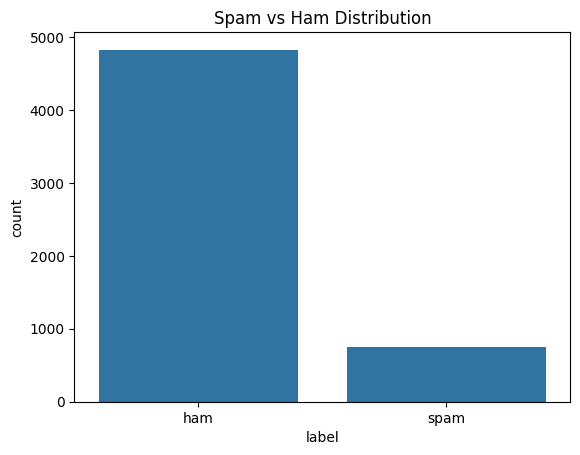

In [10]:
print(df['label'].value_counts())

sns.countplot(x=df['label'])
plt.title("Spam vs Ham Distribution")
plt.show()

In [11]:
# =========================
# 4. PREPROCESSING
# =========================
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('punkt')

stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):
    text = contractions.fix(str(text))
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'@\w+|#\w+', '', text)
    text = re.sub(r'\d+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)

    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    return ' '.join(words)

df['clean_text'] = df['text'].apply(preprocess)

df['label'] = df['label'].map({'ham': 0, 'spam': 1})

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.


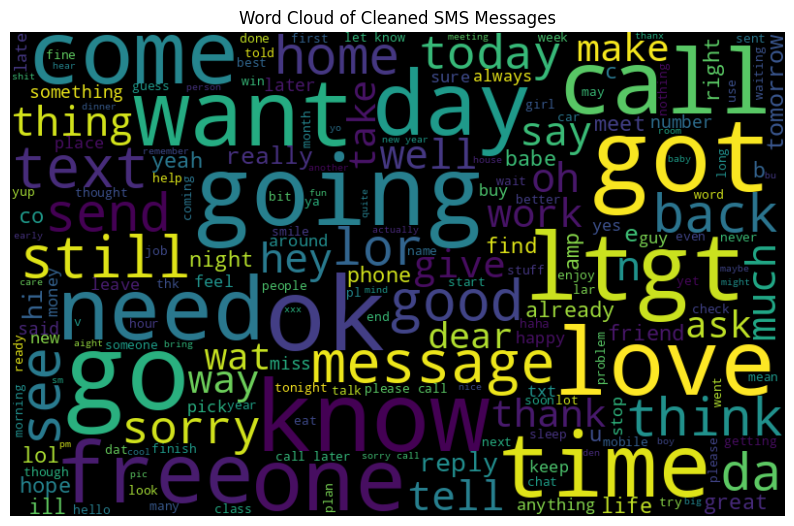

In [12]:
from wordcloud import WordCloud

all_words = ' '.join([text for text in df['clean_text']])
wordcloud = WordCloud(width=800, height=500, random_state=21, max_font_size=110).generate(all_words)

plt.figure(figsize=(10, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis('off')
plt.title('Word Cloud of Cleaned SMS Messages')
plt.show()


In [13]:
max_words = 5000

tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(df['clean_text'])

X = tokenizer.texts_to_sequences(df['clean_text'])

sequence_lengths = [len(x) for x in X]
max_len = int(np.percentile(sequence_lengths, 90))

X = pad_sequences(X, maxlen=max_len)
y = df['label'].values

# ADD THIS (IMPORTANT FIX)
vocab_size = len(tokenizer.word_index) + 1

In [14]:
# =========================
# 6. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)
# =========================
# 7. EARLY STOPPING
# =========================
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, SimpleRNN, Dropout, Dense

model = Sequential([
    Input(shape=(max_len,)),
    Embedding(input_dim=vocab_size, output_dim=64),
    SimpleRNN(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 15, 64)         │       496,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 504,513 (1.92 MB)

 Trainable params: 504,513 (1.92 MB)

 Non-trainable params: 0 (0.00 B)

In [16]:
# =========================
# 9. TRAIN MODEL
# =========================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step - accuracy: 0.9396 - loss: 0.1854 - val_accuracy: 0.9767 - val_loss: 0.0806
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - accuracy: 0.9865 - loss: 0.0521 - val_accuracy: 0.9767 - val_loss: 0.0816
Epoch 3/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9946 - loss: 0.0220 - val_accuracy: 0.9830 - val_loss: 0.0589
Epoch 4/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - accuracy: 0.9964 - loss: 0.0150 - val_accuracy: 0.9821 - val_loss: 0.0702
Epoch 5/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.9975 - loss: 0.0092 - val_accuracy: 0.9821 - val_loss: 0.0944


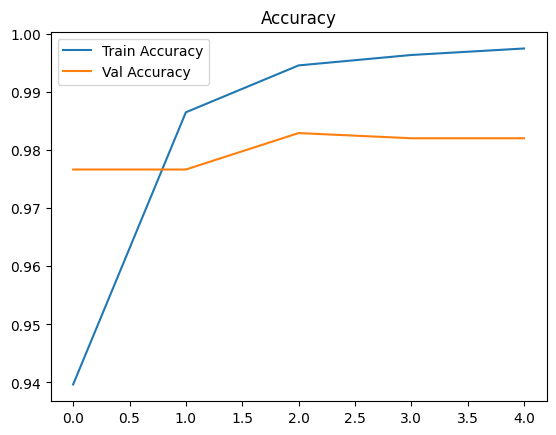

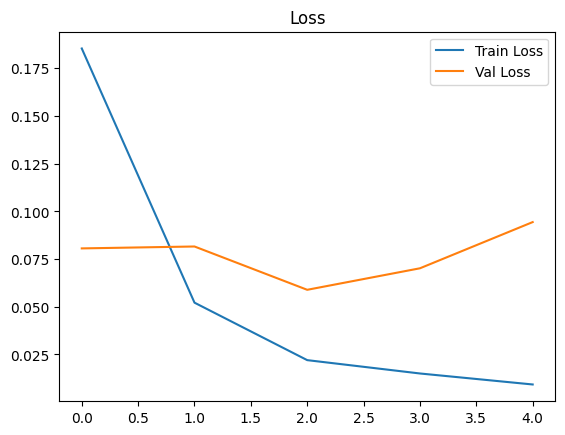

In [17]:
# =========================
# 10. PLOTS
# =========================
plt.figure()
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.legend()
plt.title("Accuracy")
plt.show()

plt.figure()
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title("Loss")
plt.show()

In [18]:
# =========================
# 11. EVALUATION
# =========================
y_pred = (model.predict(X_test) > 0.5).astype("int32")

print(classification_report(y_test, y_pred))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
              precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [26]:
from tensorflow.keras.layers import Input, Embedding, LSTM, Dropout, Dense

model_lstm = Sequential([
    Input(shape=(max_len,)),   # 👈 IMPORTANT FIX
    Embedding(input_dim=vocab_size, output_dim=64),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_lstm.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model_lstm.summary()

history_lstm = model_lstm.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=10,
    batch_size=32,
    callbacks=[early_stop]
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ (None, 15, 64)         │       496,192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 529,281 (2.02 MB)

 Trainable params: 529,281 (2.02 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 15s 61ms/step - accuracy: 0.9228 - loss: 0.2366 - val_accuracy: 0.9722 - val_loss: 0.0908
Epoch 2/10
140/140 ━━━━━━━━━━━━━━━━━━━━ 3s 17ms/step - accuracy: 0.9847 - loss: 0.0523 - val_accuracy: 0.9830 - val_loss: 0.0623


In [27]:
import gensim.downloader as api
w2v = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


In [28]:
embedding_dim = 300
embedding_matrix = np.zeros((vocab_size, embedding_dim))

for word, i in tokenizer.word_index.items():
    if i < vocab_size:
        try:
            embedding_matrix[i] = w2v[word]
        except:
            pass

In [29]:
model_w2v = Sequential([
    Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        weights=[embedding_matrix],
        input_length=max_len,
        trainable=False
    ),
    LSTM(64),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
])

model_w2v.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [30]:
history_w2v = model_w2v.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=5,
    batch_size=32,
    callbacks=[early_stop]
)

Epoch 1/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 11s 51ms/step - accuracy: 0.9336 - loss: 0.2021 - val_accuracy: 0.9525 - val_loss: 0.1275
Epoch 2/5
140/140 ━━━━━━━━━━━━━━━━━━━━ 5s 38ms/step - accuracy: 0.9731 - loss: 0.0904 - val_accuracy: 0.9623 - val_loss: 0.0874


In [31]:
# WORD2VEC EVALUATION
y_pred_w2v = (model_w2v.predict(X_test) > 0.5).astype("int32")

print("===== WORD2VEC LSTM RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_w2v))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_w2v))
print("\nClassification Report:\n", classification_report(y_test, y_pred_w2v))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step
===== WORD2VEC LSTM RESULTS =====
Accuracy: 0.9524663677130045

Confusion Matrix:
 [[955  10]
 [ 43 107]]

Classification Report:
               precision    recall  f1-score   support

           0       0.96      0.99      0.97       965
           1       0.91      0.71      0.80       150

    accuracy                           0.95      1115
   macro avg       0.94      0.85      0.89      1115
weighted avg       0.95      0.95      0.95      1115



In [32]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict using RNN model
y_pred_rnn = (model.predict(X_test) > 0.5).astype("int32")

print("===== SIMPLE RNN RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_rnn))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_rnn))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rnn))

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
===== SIMPLE RNN RESULTS =====
Accuracy: 0.9829596412556054

Confusion Matrix:
 [[962   3]
 [ 16 134]]

Classification Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99       965
           1       0.98      0.89      0.93       150

    accuracy                           0.98      1115
   macro avg       0.98      0.95      0.96      1115
weighted avg       0.98      0.98      0.98      1115



In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Predict using LSTM model
y_pred_lstm = (model_lstm.predict(X_test) > 0.5).astype("int32")

print("===== LSTM RESULTS =====")
print("Accuracy:", accuracy_score(y_test, y_pred_lstm))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred_lstm))
print("\nClassification Report:\n", classification_report(y_test, y_pred_lstm))

35/35 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
===== LSTM RESULTS =====
Accuracy: 0.9721973094170404

Confusion Matrix:
 [[965   0]
 [ 31 119]]

Classification Report:
               precision    recall  f1-score   support

           0       0.97      1.00      0.98       965
           1       1.00      0.79      0.88       150

    accuracy                           0.97      1115
   macro avg       0.98      0.90      0.93      1115
weighted avg       0.97      0.97      0.97      1115



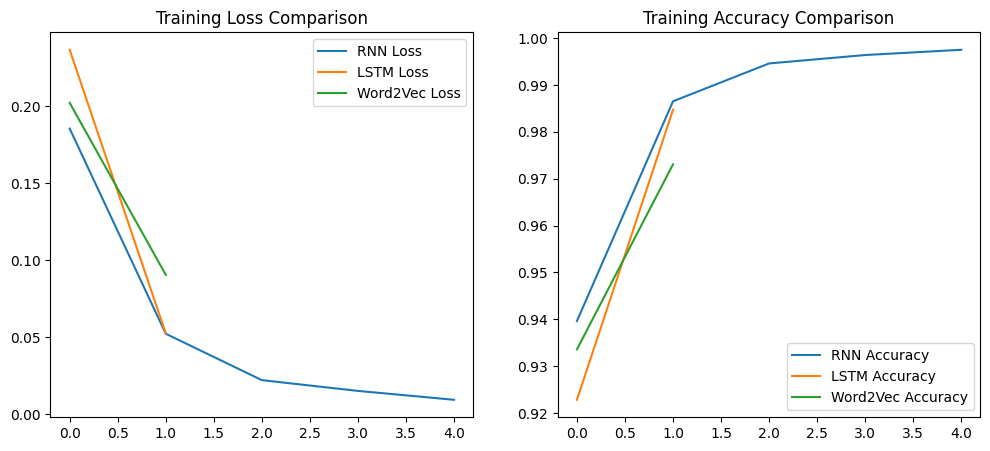

In [34]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='RNN Loss')
plt.plot(history_lstm.history['loss'], label='LSTM Loss')
plt.plot(history_w2v.history['loss'], label='Word2Vec Loss')
plt.title('Training Loss Comparison')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='RNN Accuracy')
plt.plot(history_lstm.history['accuracy'], label='LSTM Accuracy')
plt.plot(history_w2v.history['accuracy'], label='Word2Vec Accuracy')
plt.title('Training Accuracy Comparison')
plt.legend()

plt.show()


In [35]:
rnn_acc = model.evaluate(X_test, y_test, verbose=0)[1]
lstm_acc = model_lstm.evaluate(X_test, y_test, verbose=0)[1]
w2v_acc = model_w2v.evaluate(X_test, y_test, verbose=0)[1]

print("RNN:", rnn_acc)
print("LSTM:", lstm_acc)
print("Word2Vec LSTM:", w2v_acc)

RNN: 0.9829596281051636
LSTM: 0.9721972942352295
Word2Vec LSTM: 0.9524663686752319


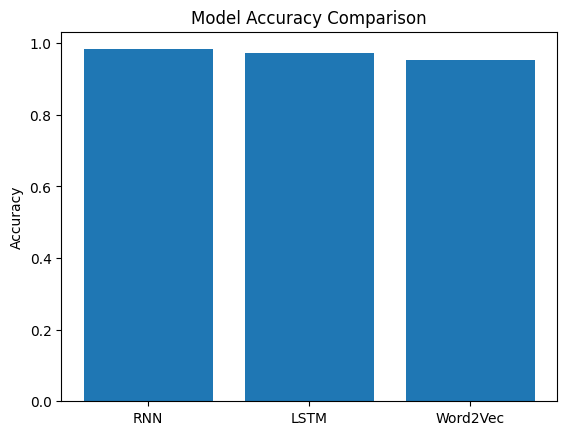

In [36]:
models = ["RNN", "LSTM", "Word2Vec"]
accuracy = [rnn_acc, lstm_acc, w2v_acc]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [37]:
import numpy as np

# Get LSTM predictions (best model usually used for error analysis)
y_pred = (model_lstm.predict(X_test) > 0.5).astype("int32").flatten()

# Find wrong predictions
wrong_idx = np.where(y_pred != y_test)[0]

print("Total wrong predictions:", len(wrong_idx))

# Show first 5 wrong examples
for i in wrong_idx[:5]:
    print("\n--- MISTAKE ---")
    X_texts = df['clean_text'].values
    print("Text:", X_texts[i])
    print("Actual:", y_test[i])
    print("Predicted:", y_pred[i])

35/35 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step
Total wrong predictions: 31

--- MISTAKE ---
Text: plane give month end
Actual: 1
Predicted: 0

--- MISTAKE ---
Text: gud mrng dear hav nice day
Actual: 1
Predicted: 0

--- MISTAKE ---
Text: o called ubandu run without installing hard diskyou use o copy important file system give repair shop
Actual: 1
Predicted: 0

--- MISTAKE ---
Text: would really appreciate call need someone talk
Actual: 1
Predicted: 0

--- MISTAKE ---
Text: okay shining meant signing sound better
Actual: 1
Predicted: 0


In [38]:
print("Total test samples:", len(y_test))
print("Total misclassified samples:", len(wrong_idx))
print("Error rate:", len(wrong_idx)/len(y_test))

Total test samples: 1115
Total misclassified samples: 31
Error rate: 0.02780269058295964


In [39]:
import gradio as gr
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_spam(message):
    # preprocess input
    clean = preprocess(message)

    # tokenize
    seq = tokenizer.texts_to_sequences([clean])

    # padding
    padded = pad_sequences(seq, maxlen=max_len)

    # prediction
    pred = model_lstm.predict(padded)[0][0]

    if pred > 0.5:
        return "🚨 Spam Message"
    else:
        return "✅ Not Spam Message"

# Create interface
interface = gr.Interface(
    fn=predict_spam,
    inputs=gr.Textbox(lines=3, placeholder="Enter SMS message here..."),
    outputs="text",
    title="SMS Spam Detection System",
    description="Type any SMS and model will predict if it's Spam or Not Spam"
)

interface.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://0739a5c73ea9e7bd32.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
